In [1]:
import sys
import os

sys.path.append(os.path.abspath(os.path.join("..")))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.preprocessing import model_features, load_processed_splits
from src.dhr_arimax import (
    HORIZONS,
    arimax_dhr_search_or_load,
    naive_single_origin,
    run_evaluation,
)

In [2]:
DATA_DIR = os.path.join("..", "data", "processed")

train_df, val_df, test_df = load_processed_splits(DATA_DIR)

features_dhr = model_features(train_df)["dhr"]
print(f"DHR features ({len(features_dhr)}): {features_dhr}")

X_train, y_train = train_df[features_dhr], train_df["energy"]
X_val, y_val = val_df[features_dhr], val_df["energy"]
X_test, y_test = test_df[features_dhr], test_df["energy"]

DHR features (20): ['cos_168_k1', 'cos_168_k2', 'cos_24_k1', 'cos_24_k2', 'cos_24_k3', 'cos_4406_k1', 'cos_8766_k1', 'cos_8766_k2', 'sin_168_k1', 'sin_168_k2', 'sin_24_k1', 'sin_24_k2', 'sin_24_k3', 'sin_4406_k1', 'sin_8766_k1', 'sin_8766_k2', 'is_weekend', 'is_holiday', 'mean_cdh', 'mean_hdh']


In [3]:
model = arimax_dhr_search_or_load(y_train, X_train)
print(model.summary())

[CACHE] File ../models/arimax_dhr.joblib already exists. Loading results...
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:               122375
Model:               SARIMAX(3, 1, 3)   Log Likelihood             -954555.551
Date:                Thu, 18 Jun 2026   AIC                        1909167.102
Time:                        12:09:27   BIC                        1909439.118
Sample:                    01-15-2002   HQIC                       1909248.910
                         - 12-31-2015                                         
Covariance Type:                  opg                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
intercept       5.6297      0.419     13.445      0.000       4.809       6.450
cos_168_k1    390.4075     51.234      7.620      0.

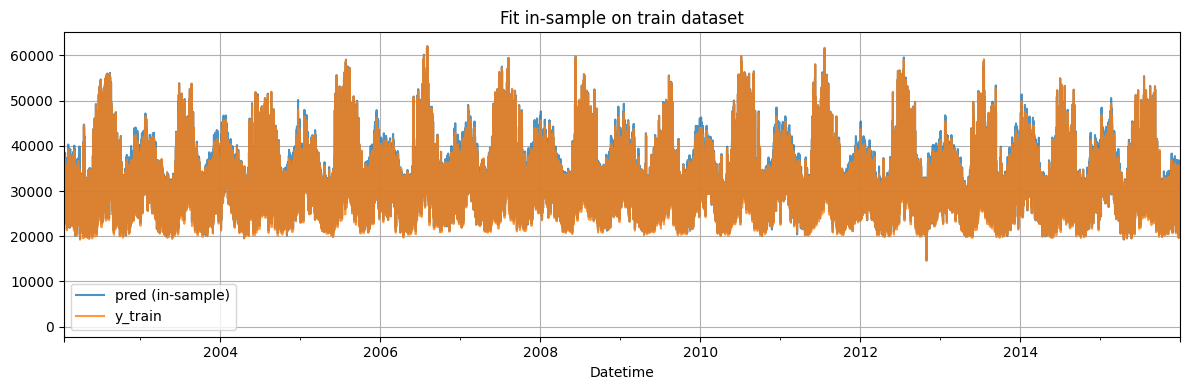

In [4]:
prediction_in_sample = model.predict_in_sample(X_train)

plt.figure(figsize=(12, 4))
prediction_in_sample.plot(label="pred (in-sample)", alpha=0.8)
y_train.plot(label="y_train", alpha=0.8)
plt.title("Fit in-sample on train dataset")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [5]:
results = run_evaluation(
    model,
    y_train,
    {"val": (X_val, y_val), "test": (X_test, y_test)},
)

metrics_df = (
    pd.DataFrame(results)
    .sort_values(["split", "horizon", "model"])
    .reset_index(drop=True)
)
metrics_df

,model,split,horizon,mae,rmse,mape
0,ARIMAX DHR,test,24,2996.757151,3570.971699,11.320858
1,Naive seasonal (lag 24),test,24,2036.000000,2213.437052,7.611078
2,ARIMAX DHR,test,168,2582.690724,3322.332402,7.942353
3,Naive seasonal (lag 168),test,168,5272.053571,5838.103424,16.029431
4,ARIMAX DHR,val,24,1860.312568,2180.037757,6.699038
5,Naive seasonal (lag 24),val,24,1059.916667,1288.033546,3.897948
6,ARIMAX DHR,val,168,3443.027741,4261.159301,10.361457
7,Naive seasonal (lag 168),val,168,5570.321429,6165.761403,16.701358


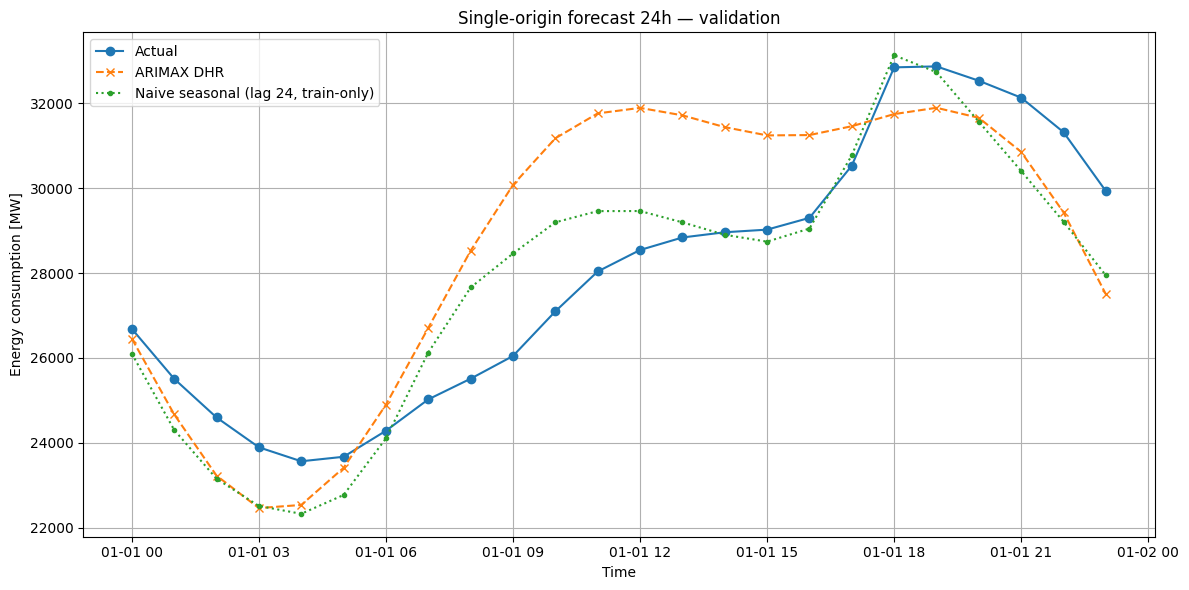

In [6]:
horizon = 24
prediction_val = model.predict(n_periods=horizon, X=X_val.iloc[:horizon])
naive_val = naive_single_origin(y_train, horizon, lag=horizon)

plt.figure(figsize=(12, 6))
plt.plot(y_val.iloc[:horizon].index, y_val.iloc[:horizon], label="Actual", marker="o")
plt.plot(
    y_val.iloc[:horizon].index,
    prediction_val,
    label="ARIMAX DHR",
    linestyle="--",
    marker="x",
)
plt.plot(
    y_val.iloc[:horizon].index,
    naive_val,
    label="Naive seasonal (lag 24, train-only)",
    linestyle=":",
    marker=".",
)
plt.title(f"Single-origin forecast {horizon}h — validation")
plt.xlabel("Time")
plt.ylabel("Energy consumption [MW]")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

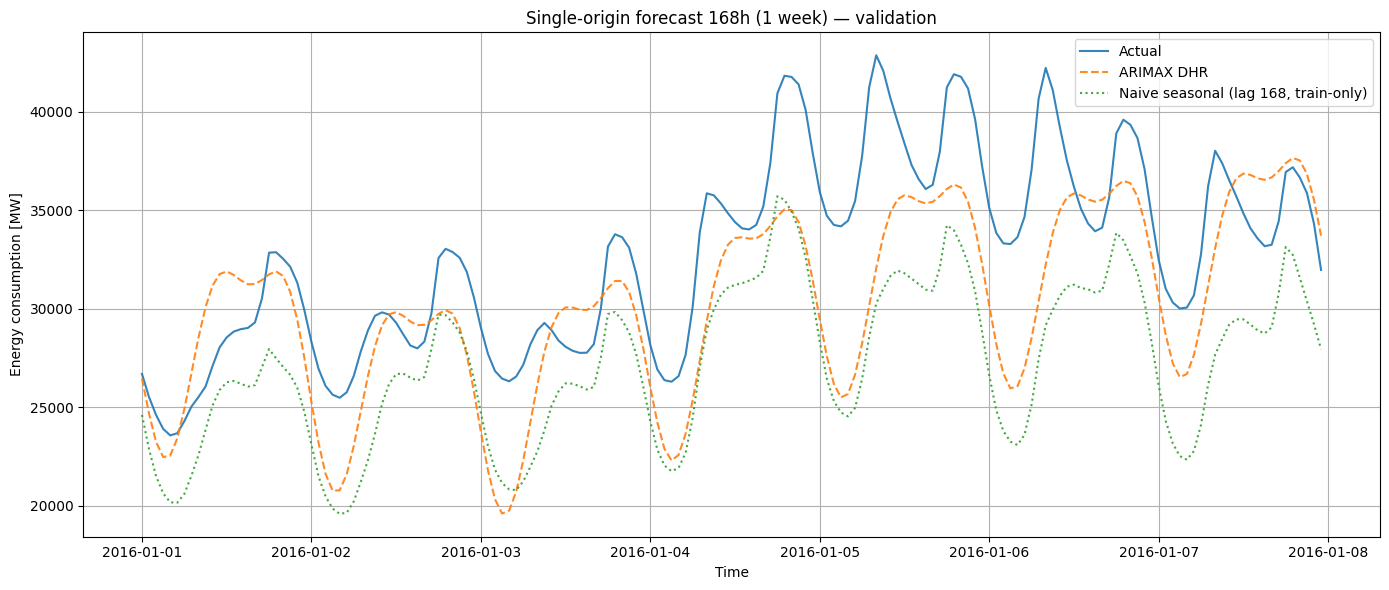

In [7]:
horizon = 168
prediction_val = model.predict(n_periods=horizon, X=X_val.iloc[:horizon])
naive_val = naive_single_origin(y_train, horizon, lag=horizon)

plt.figure(figsize=(14, 6))
plt.plot(y_val.iloc[:horizon].index, y_val.iloc[:horizon], label="Actual", alpha=0.9)
plt.plot(
    y_val.iloc[:horizon].index,
    prediction_val,
    label="ARIMAX DHR",
    linestyle="--",
    alpha=0.9,
)
plt.plot(
    y_val.iloc[:horizon].index,
    naive_val,
    label="Naive seasonal (lag 168, train-only)",
    linestyle=":",
    alpha=0.9,
)
plt.title(f"Single-origin forecast {horizon}h (1 week) — validation")
plt.xlabel("Time")
plt.ylabel("Energy consumption [MW]")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()